In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lqg import xcorr

df = pd.read_csv("data/multisensory/df_downsampled.csv")
df.head()


,session,participant,trial_number,type,vis_noise,time,lefty_pos,righty_pos,cursory_pos
0,2,135033060,7,vis,1,8.338,19.896919,17.680711,17.788407
1,2,135033060,7,vis,1,8.413,18.744622,17.681910,18.777561
2,2,135033060,7,vis,1,8.488,17.607245,17.680198,21.530017
3,2,135033060,7,vis,1,8.563,16.523169,17.680769,21.386902
4,2,135033060,7,vis,1,8.638,15.932538,17.680512,20.837665


In [45]:

df["participant"].unique()

array([135033060, 212056115])

1.059578642352777
1.0575810142506716
1.056595721654401
1.0565641133287453
1.0466913971323144
1.0467225417657429


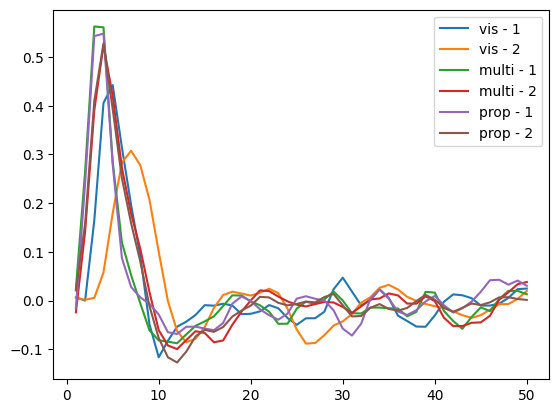

In [59]:
def prep_data(df, participant, condition, vis_noise):
    df_sub = df[
        (df["participant"] == participant)
        & (df["type"] == condition)
        & (df["vis_noise"] == vis_noise)
    ]
    
    data = []
    for trial_num, df_trial in df_sub.groupby("trial_number"):
        data.append(np.array([df_trial['cursory_pos'], df_trial['lefty_pos']]).T)

    lens = [d.shape[0] for d in data]
    min_len = min(lens)
    data = [d[:min_len] for d in data]

    return np.stack(data)


for condition in df["type"].unique():
    for vis_noise in df["vis_noise"].unique():
        data = prep_data(df, participant=135033060, condition=condition, vis_noise=vis_noise)
        print(np.diff(data[..., 0]).std())

        vels = np.diff(data, axis=1)
        lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

        plt.plot(lags[51:], correls.mean(axis=0)[51:], label=f"{condition} - {vis_noise}")
plt.legend()



In [52]:
data.shape

(8, 166, 2)

In [ ]:
import arviz as az



In [ ]:
from cppp.models.multisensory import UnisensoryDelayModel

from jax import random



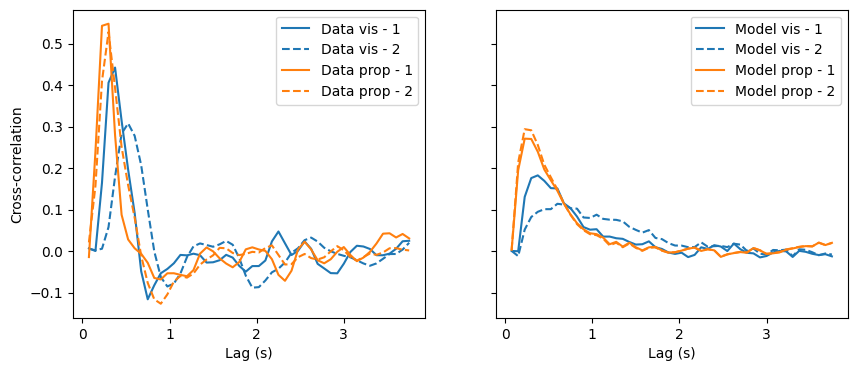

In [ ]:
delays = {"vis": 2, "prop": 1}

f, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, condition in enumerate(["vis", "prop"]):
    for vis_noise in [1, 2]:
        inference_data = az.from_netcdf(
            f"results/multisensory-mcmc-{condition}-{vis_noise}-UnisensoryDelayModel-1.nc"
        )
        summary = az.summary(inference_data)

        posterior_mean = summary["mean"].to_dict()

        model = UnisensoryDelayModel(**posterior_mean, T=data.shape[1], delay=delays[condition], dt=0.075)
        sim_data = model.simulate(
            rng_key=random.PRNGKey(0), n=100
        )

        sim_vels = np.diff(sim_data, axis=1)
        lags, sim_correls = xcorr(sim_vels[:, :, 1], sim_vels[:, :, 0], maxlags=50)

        data = prep_data(df, participant=135033060, condition=condition, vis_noise=vis_noise)
        vels = np.diff(data, axis=1)
        lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

        ax[0].plot(lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"Data {condition} - {vis_noise}", linestyle="-" if vis_noise == 1 else "--", color=f"C{i}")
        ax[1].plot(lags[51:] * 0.075, sim_correls.mean(axis=0)[51:], label=f"Model {condition} - {vis_noise}", linestyle="-" if vis_noise == 1 else "--", color=f"C{i}")

# multisensory prediction


ax[0].set_xlabel("Lag (s)")
ax[1].set_xlabel("Lag (s)")
ax[0].set_ylabel("Cross-correlation")
ax[0].set_title("Data")
ax[1].set_title("Model")
ax[0].legend()
ax[1].legend()